In [23]:
import importlib
import model
import data
import util
importlib.reload(model)
importlib.reload(data)
importlib.reload(util)

<module 'util' from 'c:\\Users\\janav\\Documents\\load forecasting\\local-stlf\\di-rnn\\util.py'>

In [24]:
import torch
from data import preprocess_data
import pandas as pd
import numpy as np
from util import calculate_metrics
import time
import matplotlib.pyplot as plt

In [25]:
def plot_data(y_true, y_pred):
    plt.figure(figsize=(30, 7))
    plt.plot(y_true, color='blue', linewidth=0.5, label='True Values (t+1)')
    plt.plot(y_pred, color='red', linewidth=0.5, label='Predicted Values (t+1)')
    plt.title("Forecast Step t+1: Predicted vs True")
    plt.xlabel("Time Step")
    plt.ylabel("Rescaled Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [26]:
def evaluate_model(model, test_data, scaler, device='cpu'):
    X_seq_test, X_per_test, y_test = test_data
    X_seq_test = torch.tensor(X_seq_test, dtype=torch.float32).to(device)
    X_per_test = torch.tensor(X_per_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

    preds = []

    with torch.no_grad():
        start_time = time.time()
        for i in range(0, len(X_seq_test)):
            seq_x = X_seq_test[i].unsqueeze(0).to(device)  # [1, m, 1]
            per_x = X_per_test[i].unsqueeze(0).to(device)  # [1, n, 1]

            pred = model(seq_x, per_x).squeeze(0)
            preds.append(pred)
        end_time = time.time()

    preds = preds = torch.stack(preds).cpu().numpy()  # [samples, horizon]
    true_vals = y_test.cpu().numpy()  # [samples, horizon]

    print(preds.min(), preds.max())
    print(true_vals.min(), true_vals.max())

    # Rescale to original units
    preds_rescaled = scaler.inverse_transform(preds)
    true_rescaled = scaler.inverse_transform(true_vals)

    print(f"\n Shapes: {preds_rescaled.shape}, {true_rescaled.shape}")

    pred_step1 = preds_rescaled[:, 0]
    true_step1 = true_rescaled[:, 0]

    return true_step1, pred_step1, calculate_metrics(true_step1, pred_step1, end_time - start_time, 'st')

In [33]:
def horizon_rolling_forecast_dirnn(model, df_all, scaler, start_time, m, n, freq, forecast_horizon, total_steps, device='cpu'):
    model.eval()
    preds = []
    predicted_values = {}  # timestamp → predicted scaled value
    current_time = start_time
    step_size = pd.to_timedelta(freq)

    with torch.no_grad():
        steps_done = 0
        while steps_done < total_steps:
            horizon = min(forecast_horizon, total_steps - steps_done)
            serial_inputs = []
            periodic_inputs = []

            for h in range(horizon):
                now = current_time + h * step_size
                all_valid = True

                # --- Serial Input ---
                s_range = pd.date_range(end=now, periods=m, freq=freq)
                s_vals = []
                for ts in s_range:
                    if ts in predicted_values:
                        s_vals.append(predicted_values[ts])
                    elif ts in df_all.index:
                        s_vals.append(df_all.loc[ts, 'scaled'])
                    else:
                        all_valid = False
                        break

                if len(s_vals) < m:
                    all_valid = False

                # --- Periodic Input ---
                p_vals = []
                for i in range(1, n + 1):
                    prev_day = now - pd.Timedelta(days=i)
                    if prev_day in predicted_values:
                        p_vals.append(predicted_values[prev_day])
                    elif prev_day in df_all.index:
                        p_vals.append(df_all.loc[prev_day, 'scaled'])
                    else:
                        all_valid = False
                        break

                if len(p_vals) < n:
                    all_valid = False

                # Only append if both are valid
                if all_valid:
                    serial_inputs.append(np.array(s_vals).reshape(m, 1))
                    periodic_inputs.append(np.array(p_vals).reshape(n, 1))
                else:
                    break

            if len(serial_inputs) < horizon or len(periodic_inputs) < horizon:
                print("⚠️ Not enough context to continue prediction. Stopping early.", flush=True)
                break

            # Convert to tensors
            x_seq = torch.tensor(serial_inputs[-1], dtype=torch.float32).unsqueeze(0).to(device)  # [1, m, 1]
            x_per = torch.tensor(periodic_inputs[-1], dtype=torch.float32).unsqueeze(0).to(device)  # [1, n, 1]


            # Predict
            y_scaled = model(x_seq, x_per).cpu().numpy()  # [horizon]

            # Save predictions and update state
            for h in range(horizon):
                ts = current_time + h * step_size
                pred_val = float(y_scaled[0, h])  # ✅ Access from batch 0, horizon h
                predicted_values[ts] = pred_val
                preds.append(pred_val)



            steps_done += horizon
            current_time += horizon * step_size

            print(f"\r✅ Forecasted {steps_done}/{total_steps} steps", end="", flush=True)

    preds = np.array(preds).reshape(-1, 1)
    print("Scaled preds: max =", preds.max(), ", min =", preds.min(), flush=True)
    return scaler.inverse_transform(preds).flatten()


In [28]:
device = "cpu"
csv_path = 'data/mm79158.csv'
m = 24 * 14 # lookback sequence 14 days
n = 14 # same hour past 14 days
horizon = 1 


data, scaler, df_all = preprocess_data(csv_path, m=m, n=n, freq='1h', horizon=1)
train_data = data['train']
val_data = data['val']
test_data = data['test']

model = torch.load('models/model_epoch_20.pt')

📥 Loading and preprocessing data...
🔢 Scaling values...
🧩 Constructing input sequences...
✅ Dataset sizes → Train: 17956, Val: 2992, Test: 8979


C:\Users\janav\AppData\Local\Temp\ipykernel_34868\1960940846.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('models/model_epoch_20.pt')


In [29]:
y_true, y_pred, results =  evaluate_model(model, test_data, scaler)
results_df = pd.DataFrame([results])

0.017836593 0.63165146
0.008222805 0.89497757

 Shapes: (8979, 1), (8979, 1)


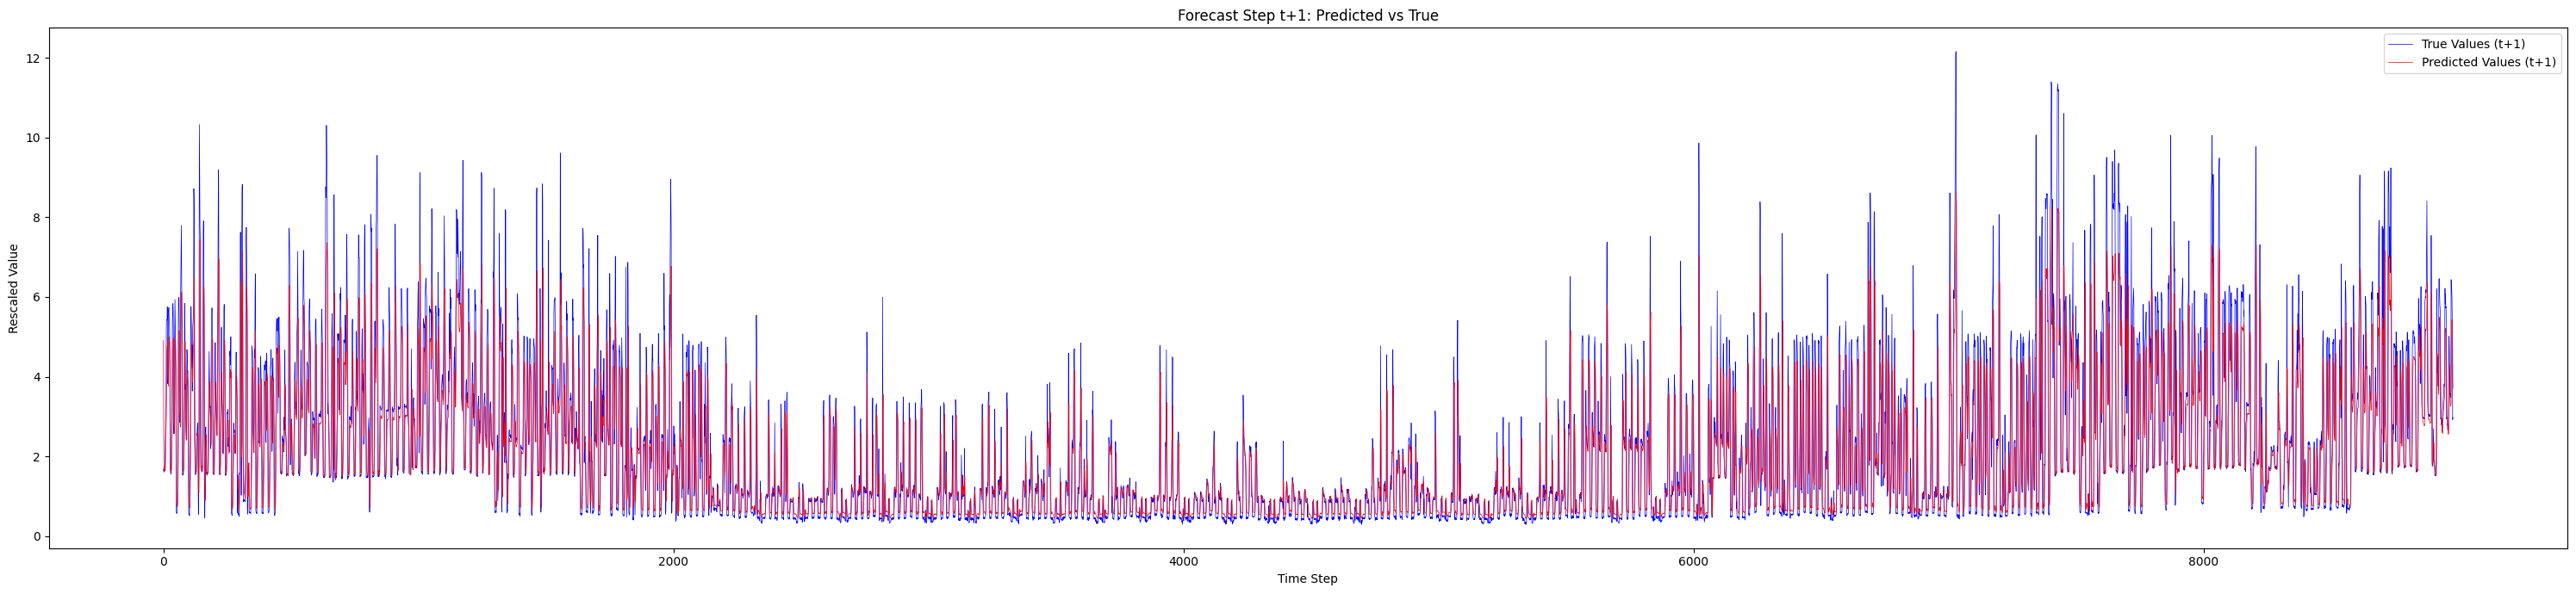

In [30]:
plot_data(y_true, y_pred)

In [34]:
# Use the last timestamp from val to start forecasting into test
val_end_idx = int(len(df_all) * 0.7) - 1  # 60% train + 10% val = 70%
start_time = df_all.index[val_end_idx + 1]

# Total steps to forecast: full test target length
total_steps = test_data[2].shape[0]

# Run rolling forecast using the updated method
s = time.time()
y_auto = horizon_rolling_forecast_dirnn(
    model=model,
    df_all=df_all,
    start_time=start_time,
    total_steps=total_steps,
    forecast_horizon=horizon,
    m=m,
    n=n,
    freq='1h',
    scaler=scaler,
    device='cpu'
)
e = time.time()

results_df = pd.concat([results_df, pd.DataFrame([calculate_metrics(y_true, y_auto, e - s, 'lt')])])


✅ Forecasted 8979/8979 stepsScaled preds: max = 0.5429295897483826 , min = 0.029457010328769684


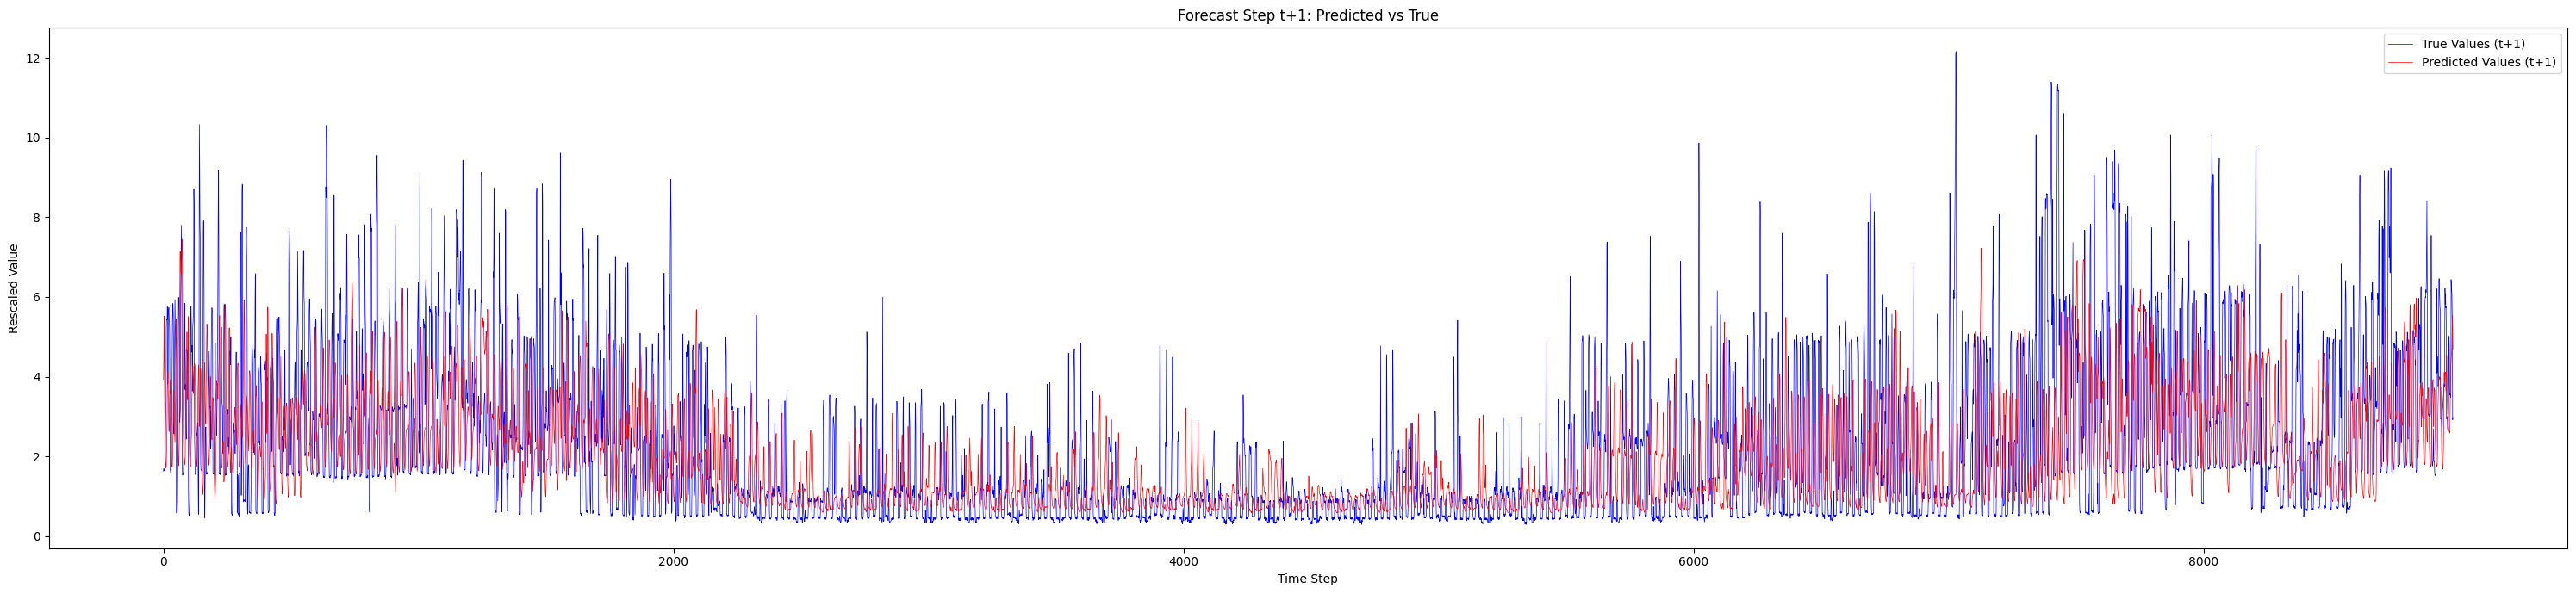

In [35]:
plot_data(y_true, y_auto)

In [36]:
pred_df = pd.DataFrame({
    'y_true': y_true.flatten(),
    'y_st': y_pred.flatten(),
    'y_lt': y_auto.flatten()
})

results_df.to_csv('logs/prediction_eval.csv', index=False)
pred_df.to_csv('logs/prediction_data.csv', index=False)